In [4]:
!pip install mlxtend
!pip install onnxmltools
!pip install onnxruntime
!pip install skl2onnx


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 352.5/352.5 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 85.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 113.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 315.5/315.5 kB 17.4 MB/s eta 0:00:00


In [5]:
import numpy as np
import torch
import pandas as pd
import sklearn
import random

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

from mlxtend.plotting import heatmap
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score
import xgboost as xgb
import onnxruntime as rt
import onnxmltools

from skl2onnx.common.data_types import FloatTensorType

In [6]:
batch_size    = 32
learning_rate = 0.003
N_Epochs      = 80
epsilon       = 1e-4
seed          = 42
np.random.seed(seed); random.seed(seed); torch.manual_seed(seed)


In [7]:
path_data = '/content/drive/MyDrive/waterQuality1.csv'
raw = pd.read_csv(path_data, delimiter=",")

bad_tokens = ['#NUM!','#DIV/0!','N/A','NA','null','Null','NULL','nan','NaN','']
df = (raw.replace(bad_tokens, np.nan).apply(pd.to_numeric, errors='coerce'))

target = df.columns[-1]
X_df = df.drop(columns=[target])
y_sr = df[target]

X_df = X_df.fillna(X_df.mean(numeric_only=True))
if y_sr.isnull().any(): y_sr = y_sr.fillna(y_sr.mode().iloc[0])
y_sr = y_sr.astype(int)

df_clean = pd.concat([X_df, y_sr.rename(target)], axis=1)
df_clean.head()


,aluminium,ammonia,arsenic,barium,cadmium,chloramine,chromium,copper,flouride,bacteria,...,lead,nitrates,nitrites,mercury,perchlorate,radium,selenium,silver,uranium,is_safe
0,1.65,9.08,0.04,2.85,0.007,0.35,0.83,0.17,0.05,0.20,...,0.054,16.08,1.13,0.007,37.75,6.78,0.08,0.34,0.02,1
1,2.32,21.16,0.01,3.31,0.002,5.28,0.68,0.66,0.90,0.65,...,0.100,2.01,1.93,0.003,32.26,3.21,0.08,0.27,0.05,1
2,1.01,14.02,0.04,0.58,0.008,4.24,0.53,0.02,0.99,0.05,...,0.078,14.16,1.11,0.006,50.28,7.07,0.07,0.44,0.01,0
3,1.36,11.33,0.04,2.96,0.001,7.23,0.03,1.66,1.08,0.71,...,0.016,1.41,1.29,0.004,9.12,1.72,0.02,0.45,0.05,1
4,0.92,24.33,0.03,0.20,0.006,2.67,0.69,0.57,0.61,0.13,...,0.117,6.74,1.11,0.003,16.90,2.41,0.02,0.06,0.02,1


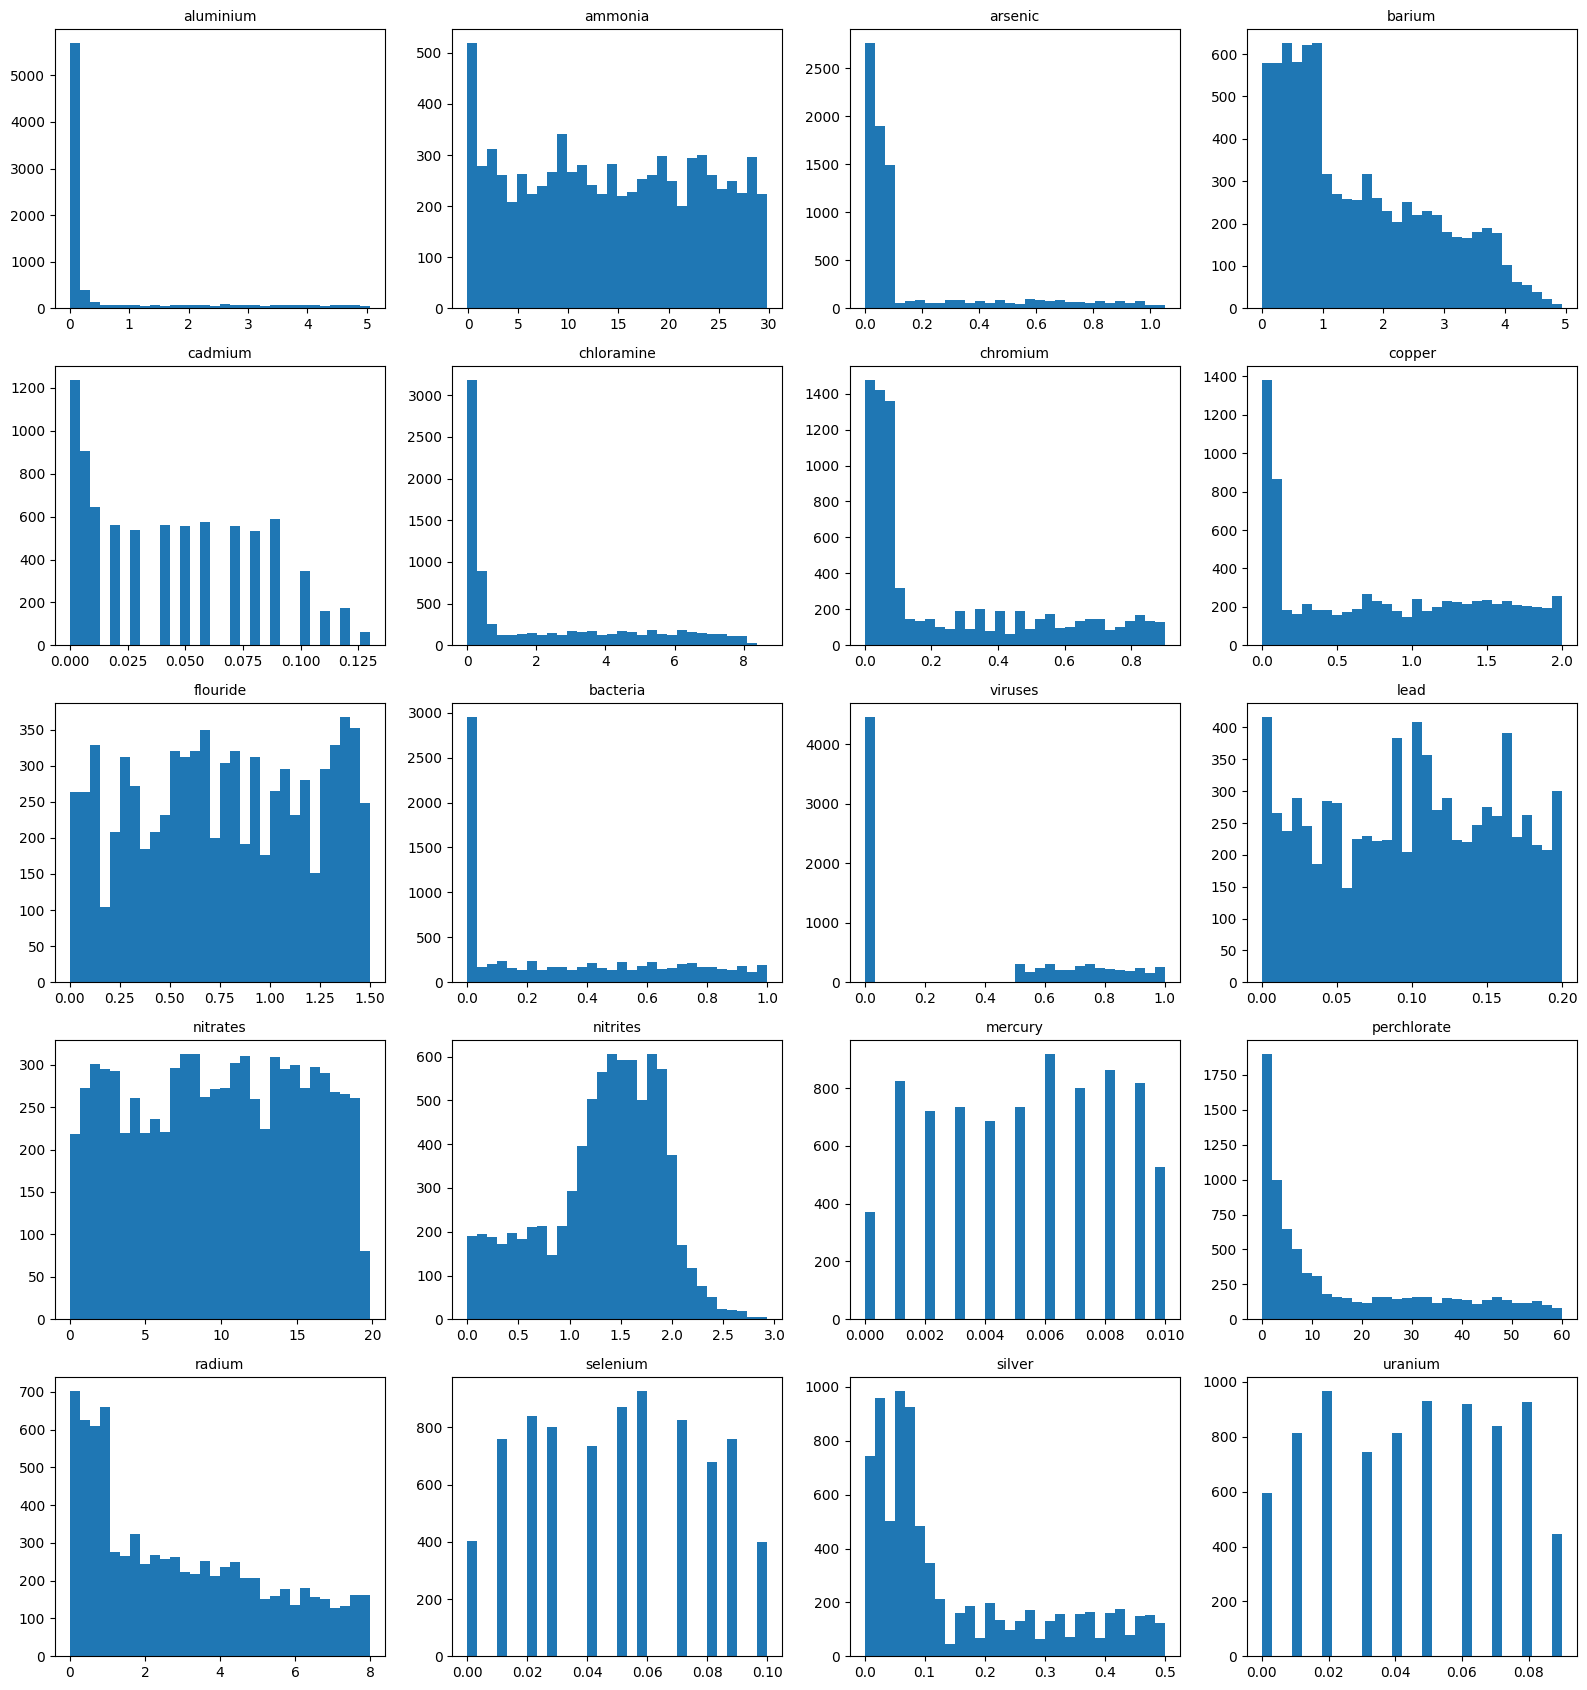

In [8]:
feat_cols = df_clean.columns[:-1].tolist()
n = len(feat_cols)
rows = int(np.ceil(n/4))
plt.figure(figsize=(16, 3.4*rows))
for i,c in enumerate(feat_cols, 1):
    ax = plt.subplot(rows, 4, i)
    ax.hist(df_clean[c].values, bins=30)
    ax.set_title(c, fontsize=10)
plt.tight_layout(); plt.show()


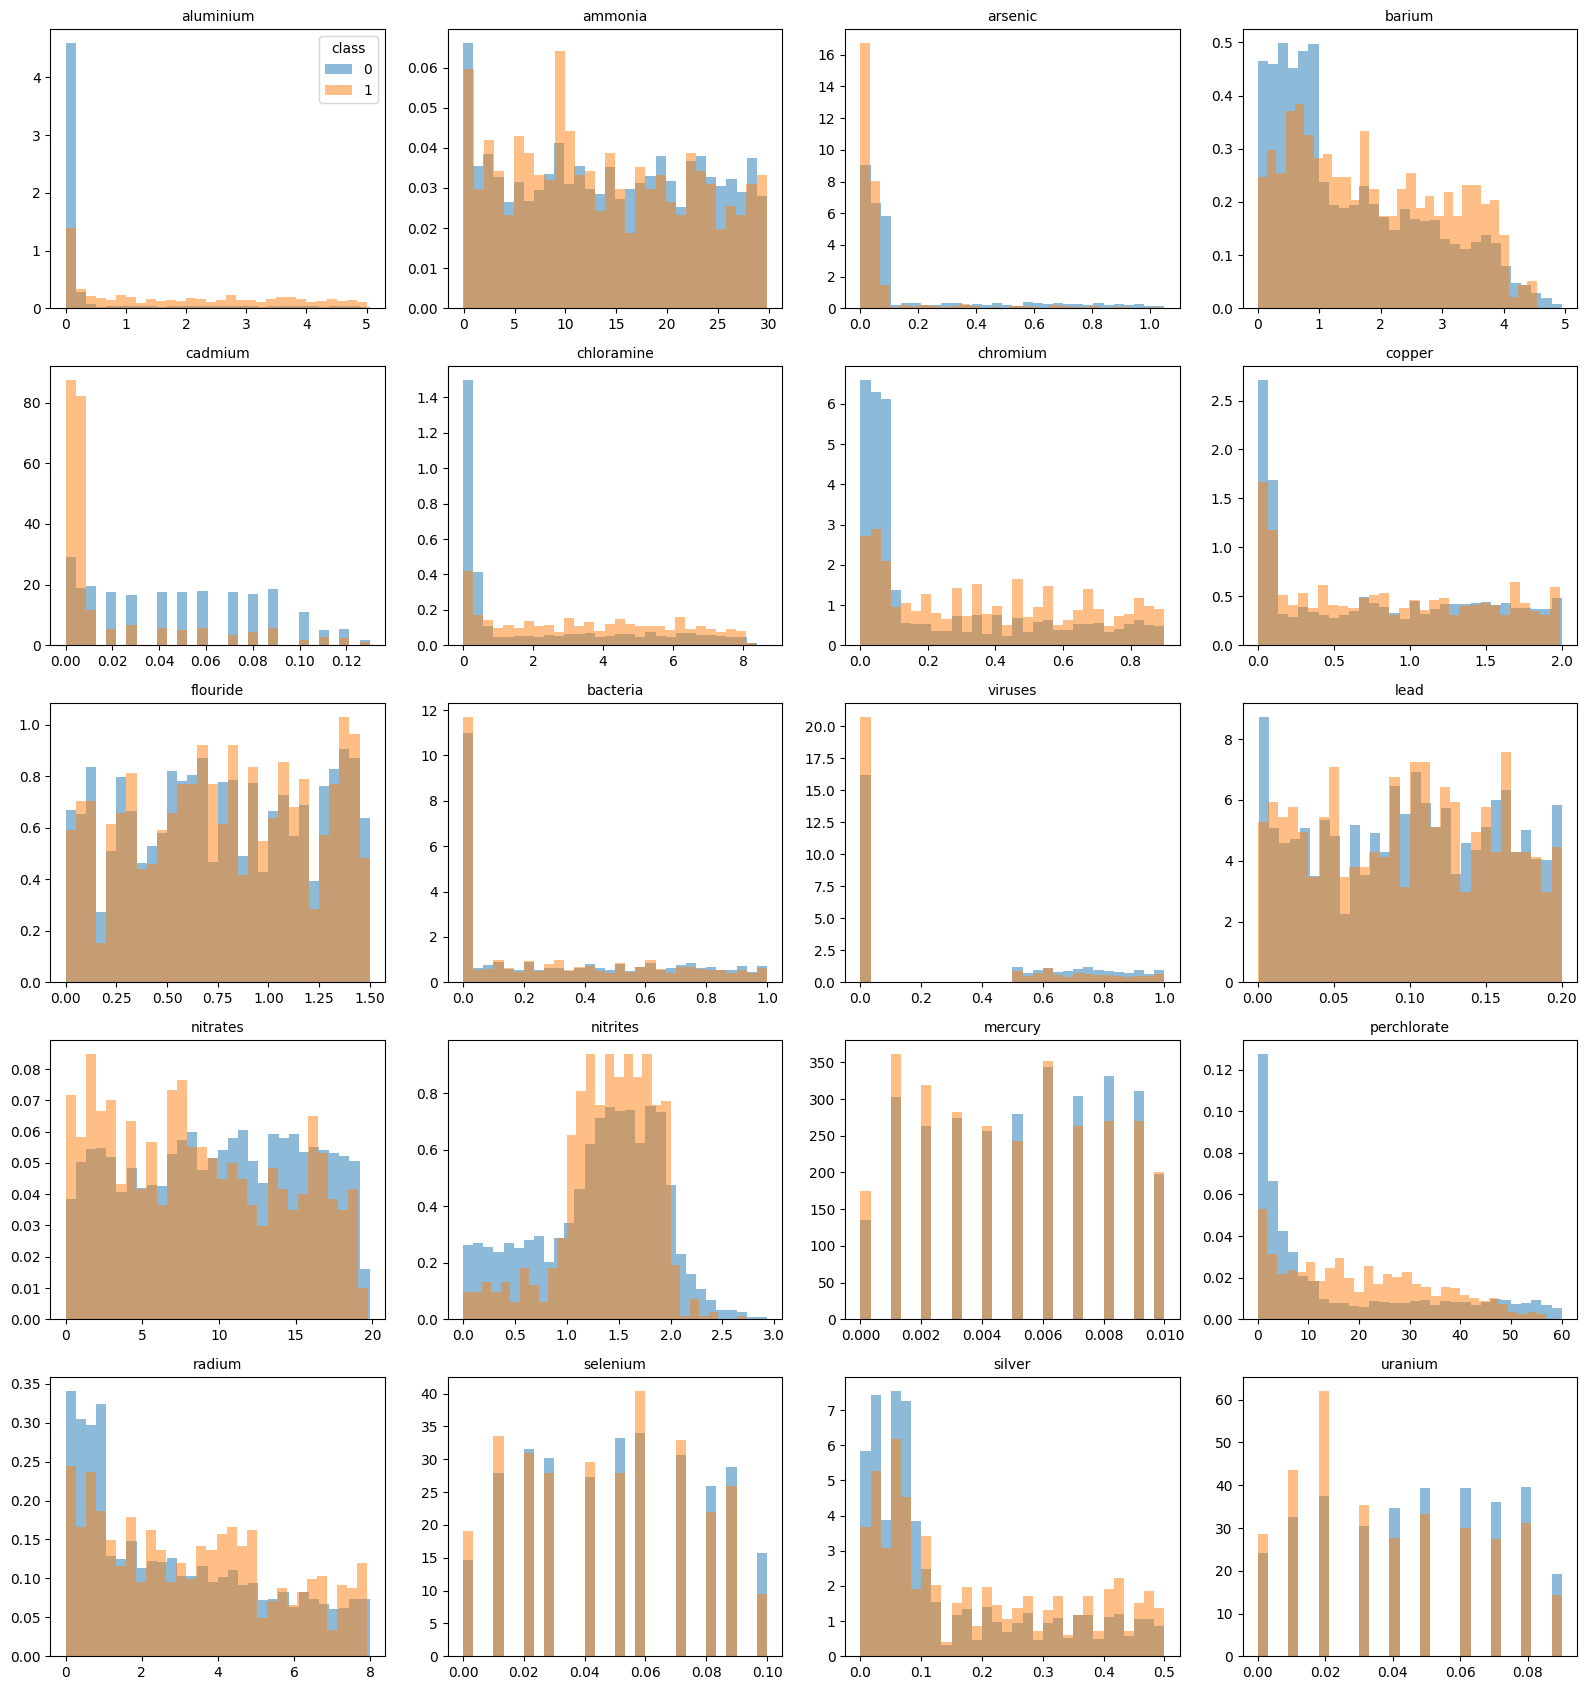

In [9]:
yname = df_clean.columns[-1]
classes = sorted(df_clean[yname].astype(int).unique().tolist())
colors = ['tab:blue','tab:orange','tab:green','tab:red','tab:purple','tab:brown']
rows = int(np.ceil(len(feat_cols)/4))
plt.figure(figsize=(16, 3.4*rows))
for i,c in enumerate(feat_cols, 1):
    ax = plt.subplot(rows, 4, i)
    for j,cl in enumerate(classes):
        vals = df_clean.loc[df_clean[yname]==cl, c].values
        ax.hist(vals, bins=30, alpha=0.5, label=str(cl), color=colors[j%len(colors)], density=True)
    ax.set_title(c, fontsize=10)
    if i==1: ax.legend(title='class')
plt.tight_layout(); plt.show()


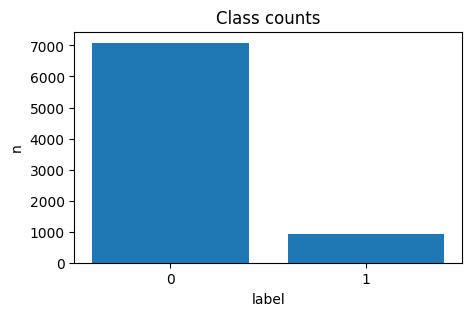

In [10]:
counts = df_clean[yname].value_counts().sort_index()
plt.figure(figsize=(5,3))
plt.bar(counts.index.astype(str), counts.values)
plt.title('Class counts'); plt.xlabel('label'); plt.ylabel('n'); plt.show()


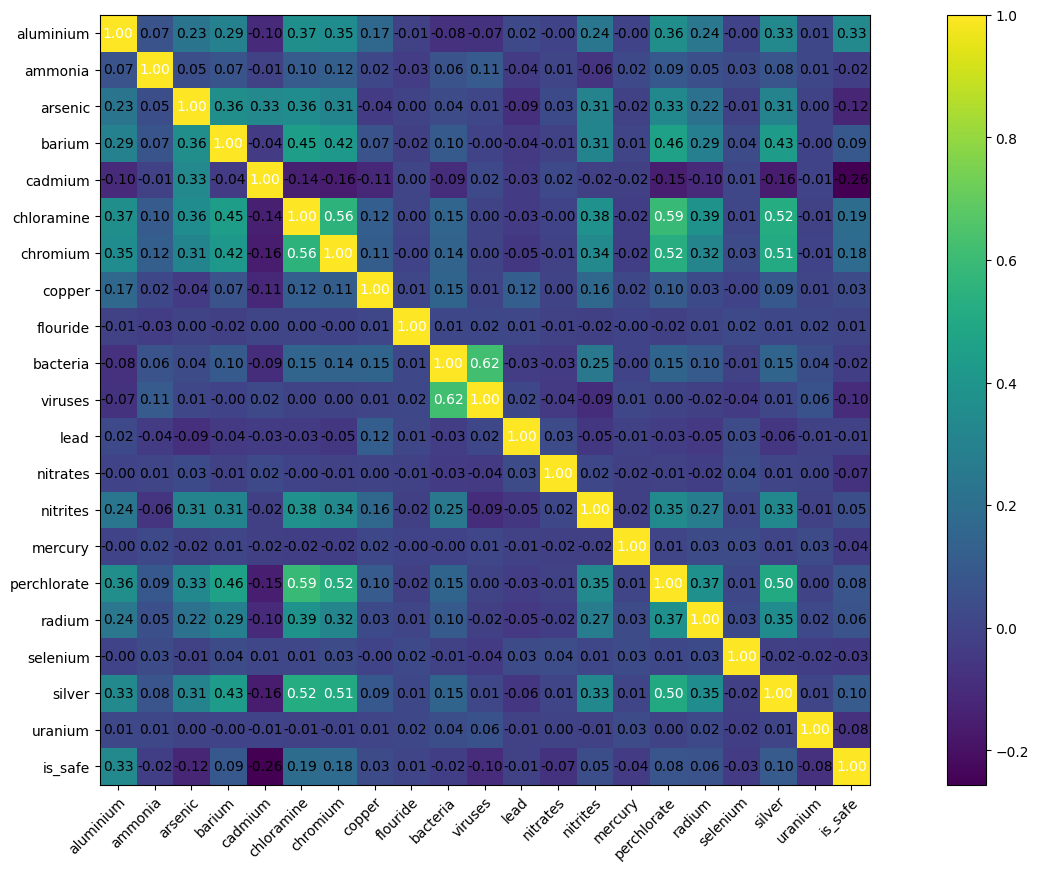

In [11]:
cols = df_clean.columns.tolist()
cm = np.corrcoef(df_clean[cols].values.T)
heatmap(cm, row_names=cols, column_names=cols, figsize=(20,10))
plt.show()


In [12]:
A = df_clean.to_numpy()
X = A[:, :-1].astype(np.float32)
y = A[:, -1].astype(int)
n_features = X.shape[1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=seed, shuffle=True, stratify=y
)

X_train_tr = torch.from_numpy(X_train)
X_test_tr  = torch.from_numpy(X_test)
y_train_tr = torch.from_numpy(y_train).long()
y_test_tr  = torch.from_numpy(y_test).long()

x_means      = X_train_tr.mean(0, keepdim=True)
x_deviations = X_train_tr.std(0, keepdim=True) + epsilon

train_dl = DataLoader(TensorDataset(X_train_tr, y_train_tr), batch_size=batch_size, shuffle=True)
test_dl  = DataLoader(TensorDataset(X_test_tr,  y_test_tr ), batch_size=batch_size, shuffle=False)


In [13]:
class LinCls(nn.Module):
    def __init__(self, xm, xd):
        super().__init__()
        self.xm, self.xd = xm, xd
        self.fc = nn.Linear(20, 2)
    def forward(self,x):
        x = (x - self.xm) / self.xd
        return self.fc(x)

class MLP_Cls(nn.Module):
    def __init__(self, xm, xd):
        super().__init__()
        self.xm, self.xd = xm, xd
        self.fc1 = nn.Linear(20, 12)
        self.a1  = nn.Sigmoid()
        self.drop= nn.Dropout(0.25)
        self.fc2 = nn.Linear(12, 2)
    def forward(self,x):
        x = (x - self.xm) / self.xd
        x = self.a1(self.fc1(x))
        x = self.drop(x)
        return self.fc2(x)

class DL_Cls(nn.Module):
    def __init__(self, xm, xd):
        super().__init__()
        self.xm, self.xd = xm, xd
        self.fc1 = nn.Linear(20, 24); self.a1 = nn.ReLU()
        self.fc2 = nn.Linear(24, 12); self.a2 = nn.ReLU()
        self.fc3 = nn.Linear(12, 2)
    def forward(self,x):
        x = (x - self.xm) / self.xd
        x = self.a1(self.fc1(x))
        x = self.a2(self.fc2(x))
        return self.fc3(x)


In [14]:
def train_model(model):
    opt = torch.optim.Adam(model.parameters(), lr=learning_rate)
    loss_fn = nn.CrossEntropyLoss()
    for e in range(N_Epochs):
        for xb, yb in train_dl:
            logits = model(xb)
            loss = loss_fn(logits, yb)
            opt.zero_grad(); loss.backward(); opt.step()
        if e%10==0: print(e, float(loss.detach()))
    return model


In [15]:
def print_metrics_function(y_true, y_pred):
    yt = y_true.cpu().numpy().astype(int)
    yp = y_pred.cpu().numpy().astype(int)
    acc = accuracy_score(yt, yp)
    cm  = confusion_matrix(yt, yp, labels=[0,1])
    prec= precision_score(yt, yp, zero_division=0)
    rec = recall_score(yt, yp, zero_division=0)
    f1  = f1_score(yt, yp, zero_division=0)
    print("Accuracy:", round(acc,3))
    print("Confusion Matrix:"); print(cm)
    print("Precision:", round(prec,3))
    print("Recall:", round(rec,3))
    print("F1-measure:", round(f1,3))

model = DL_Cls(x_means, x_deviations)
model = train_model(model)

with torch.no_grad():
    for x_real, y_real in test_dl:
        y_pred = model(x_real)
        _, indeces = torch.max(y_pred, dim=1)
        preds = indeces
        print_metrics_function(y_real, preds)
        break


0 0.15480175614356995
10 0.05332903191447258
20 0.017324307933449745
30 0.09414546191692352
40 0.11797017604112625
50 0.05094347521662712
60 0.07116343826055527
70 0.10451692342758179
Accuracy: 0.969
Confusion Matrix:
[[27  0]
 [ 1  4]]
Precision: 1.0
Recall: 0.8
F1-measure: 0.889


In [16]:
all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in test_dl:
        logits = model(xb)
        preds = torch.argmax(logits, dim=1)
        all_preds.append(preds.cpu().numpy())
        all_true.append(yb.cpu().numpy())
all_preds = np.concatenate(all_preds)
all_true  = np.concatenate(all_true)
print(classification_report(all_true, all_preds, zero_division=0))


NameError: name 'classification_report' is not defined

In [17]:
lin = train_model(LinCls(x_means, x_deviations))
mlp = train_model(MLP_Cls(x_means, x_deviations))

def f1_eval(m):
    p, t = [], []
    with torch.no_grad():
        for xb, yb in test_dl:
            logits = m(xb)
            preds = torch.argmax(logits, dim=1)
            p.append(preds.cpu().numpy()); t.append(yb.cpu().numpy())
    p = np.concatenate(p); t = np.concatenate(t)
    return f1_score(t, p, zero_division=0)

print("F1 Linear:", round(f1_eval(lin),4))
print("F1 MLP   :", round(f1_eval(mlp),4))
print("F1 DL    :", round(f1_eval(model),4))


0 0.4039449691772461
10 0.3431750535964966
20 0.22780193388462067
30 0.08997920900583267
40 0.08858455717563629
50 0.3581310212612152
60 0.40482044219970703
70 0.30371206998825073
0 0.36759185791015625
10 0.29881787300109863
20 0.09717967361211777
30 0.20199652016162872
40 0.13057947158813477
50 0.11841534823179245
60 0.10115286707878113
70 0.10864665359258652
F1 Linear: 0.4689
F1 MLP   : 0.6582
F1 DL    : 0.7803


In [18]:
best_model = model
best_model.eval()
dummy = torch.randn(1, 20)
torch.onnx.export(
    best_model, dummy, "DL_WaterQuality_Cls.onnx",
    verbose=False, input_names=["input1"], output_names=["output1"]
)


/tmp/ipython-input-3026339829.py:4: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(


In [19]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def print_metrics_function(y_true, y_pred):
    yt = y_true.detach().cpu().numpy().astype(int).ravel()
    yp = y_pred.detach().cpu().numpy().astype(int).ravel()
    acc  = accuracy_score(yt, yp)
    cm   = confusion_matrix(yt, yp, labels=[0,1])
    prec = precision_score(yt, yp, zero_division=0)
    rec  = recall_score(yt, yp, zero_division=0)
    f1   = f1_score(yt, yp, zero_division=0)
    print("Accuracy:", round(acc, 2))
    print("Confusion Matrix:")
    print(cm)
    print("Precision:", round(prec, 3))
    print("Recall:", round(rec, 3))
    print("F1-measure:", round(f1, 3))


In [20]:
with torch.no_grad():
    for x_real, y_real in test_dl:
        y_pred = model(x_real)
        vals, indeces = torch.max(y_pred, dim=1)
        preds = indeces
        print_metrics_function(y_real, preds)
        break


Accuracy: 0.97
Confusion Matrix:
[[27  0]
 [ 1  4]]
Precision: 1.0
Recall: 0.8
F1-measure: 0.889


In [21]:
all_preds, all_true = [], []
with torch.no_grad():
    for xb, yb in test_dl:
        logits = model(xb)
        preds = torch.argmax(logits, dim=1)
        all_preds.append(preds.cpu().numpy())
        all_true.append(yb.cpu().numpy())
all_preds = np.concatenate(all_preds)
all_true  = np.concatenate(all_true)

from sklearn.metrics import classification_report
print(classification_report(all_true, all_preds, zero_division=0, target_names=['not_potable','potable']))


              precision    recall  f1-score   support

 not_potable       0.97      0.98      0.97      1418
     potable       0.82      0.74      0.78       182

    accuracy                           0.95      1600
   macro avg       0.90      0.86      0.88      1600
weighted avg       0.95      0.95      0.95      1600



In [22]:
# go to the web folder (where index.html & app.js live)
%cd /content/water-quality-ml

# copy from where you exported it (adjust the left path if needed)
!cp /content/DL_WaterQuality_Cls.onnx ./model.onnx   # rename while copying

# confirm all four files are together
!ls -l


[Errno 2] No such file or directory: '/content/water-quality-ml'
/content
total 24
-rw-r--r-- 1 root root 4434 Nov 10 06:59 DL_WaterQuality_Cls.onnx
drwx------ 5 root root 4096 Nov 10 06:49 drive
-rw-r--r-- 1 root root 4434 Nov 10 06:59 model.onnx
drwxr-xr-x 1 root root 4096 Nov  5 14:33 sample_data


In [23]:
import os, glob
print("cwd:", os.getcwd())
print("Here?", os.path.exists("DL_WaterQuality_Cls.onnx"))
print("Matches:", glob.glob("/content/**/*.onnx", recursive=True)[:10])


cwd: /content
Here? True
Matches: ['/content/DL_WaterQuality_Cls.onnx', '/content/model.onnx']


In [24]:
%cd /content/water-quality-ml
!cp /content/DL_WaterQuality_Cls.onnx ./model.onnx   # overwrite current model
!ls -l


[Errno 2] No such file or directory: '/content/water-quality-ml'
/content
total 24
-rw-r--r-- 1 root root 4434 Nov 10 06:59 DL_WaterQuality_Cls.onnx
drwx------ 5 root root 4096 Nov 10 06:49 drive
-rw-r--r-- 1 root root 4434 Nov 10 07:01 model.onnx
drwxr-xr-x 1 root root 4096 Nov  5 14:33 sample_data
